In [1]:
#Import block: 
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import pandas as pd

from iminuit import Minuit, cost
from scipy.integrate import quad

r = np.random
r.seed(1)


## Problem 1: Exam in Advanced Methods in Applied Statistics
Author: Aske Roelshøj

KU-ID: KVF851

Date(s): Thurs. March 26 to Fri. March 27, 2026

## 1a + 1b

In [2]:
#Read data: 
data = pd.read_csv('Data/Exam_2026_Prob1.txt', delimiter = ' ', header = None)
data

,0,1,2,3,4,5
0,7.076218,0.083584,4.0,1.212479,2.470023,1.740495
1,6.182521,0.810306,4.0,1.151079,2.023988,7.642150
2,6.680523,0.857215,6.0,1.106831,1.136348,-0.798234
3,6.467101,0.222412,6.0,1.101607,2.469432,0.421692
4,6.320712,0.189092,4.0,1.111395,0.732828,1.676644
...,...,...,...,...,...,...
4116,6.188588,0.897227,1.0,1.096528,0.993603,0.418027
4117,6.041560,0.892445,7.0,1.192016,0.980775,6.964994
4118,8.616117,0.182497,9.0,1.119295,1.011689,6.066669
4119,7.370410,0.725753,8.0,1.052179,0.392890,2.661567


In [43]:
x1, x3, x4 = data[0], data[2], data[3]

In [ ]:
#Rasterscan function. Code is inspired by Sagar Clemensen's raster scan function. 
def raster_scan_llh(x, func, param_ranges, num_points=100):
    param_names = list(param_ranges.keys())
    n_params = len(param_names)
    grids = [np.linspace(*param_ranges[name], num_points) for name in param_names]

    def log_likelihood(*params):
        return -np.sum(np.log(func(x, *params)))

    if n_params == 1:
        values = np.array([log_likelihood(v) for v in grids[0]]) 
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(grids[0], values, color='steelblue')
        ax.set_xlabel(param_names[0])
        ax.set_ylabel('-LLH value')
        ax.set_title(f'Raster Scan — {param_names[0]}')
        best_idx = np.nanargmin(values)
        best_x = grids[0][best_idx]
        best_val = values[best_idx]
        ax.axvline(best_x, color='k', ls='--', label=f'Scan min: {param_names[0]} = {best_x:.3f}, -LLH={best_val:.2f}')
        ax.legend()
        return best_x, best_val

    if n_params == 2:
        g0, g1 = np.meshgrid(grids[0], grids[1])
        points = np.vstack([g0.ravel(), g1.ravel()]).T
        values = np.array([log_likelihood(*p) for p in points]).reshape(g0.shape) 
        fig, ax = plt.subplots(figsize=(8, 6))
        pcm = ax.pcolormesh(g0, g1, values, cmap='jet', shading='auto')
        plt.colorbar(pcm, ax=ax, label='-LLH value')
        flat_idx = np.nanargmin(values)
        best_idx = np.unravel_index(flat_idx, values.shape)
        best_x = g0[best_idx]
        best_y = g1[best_idx]
        best_val = values[best_idx]
        ax.plot(best_x, best_y, 'rx', ms=8, label=f'Scan min: ({best_x:.3f}, {best_y:.3f})  -LLH={best_val:.2f}')
        ax.set_xlabel(param_names[0])
        ax.set_ylabel(param_names[1])
        ax.set_title('Raster Scan — ' + ' vs '.join(np.flipud(param_names)))
        ax.legend()
        return (best_x, best_y), best_val

In [45]:
#And minimizer: 
def minimizer(x, func, params, limits = None, fixed_params = None):

    # Dynamically accept any number of parameters
    def log_likelihood(*params):
        return -np.sum(np.log(func(x, *params)))
    
    m = Minuit(log_likelihood, *params)
    if limits is not None:
        for i, (low, high) in enumerate(limits):
            m.limits[i] = (low, high)
    if fixed_params is not None:
        for i, val in fixed_params.items():
            m.fixed[i] = True
            m.values[i] = val
    m.migrad()  # Minimize
    
    print(f"Estimated parameters: {m.values}")
    print(f"Parameter errors: {m.errors}")
    
    min_log_likelihood = m.fval
    print(f"Minimum log-likelihood: {min_log_likelihood}")
    
    return m.values, m.errors, min_log_likelihood

((np.float64(5.252525252525253), np.float64(-1.0101010101010104)),
 np.float64(5082.571875116953))

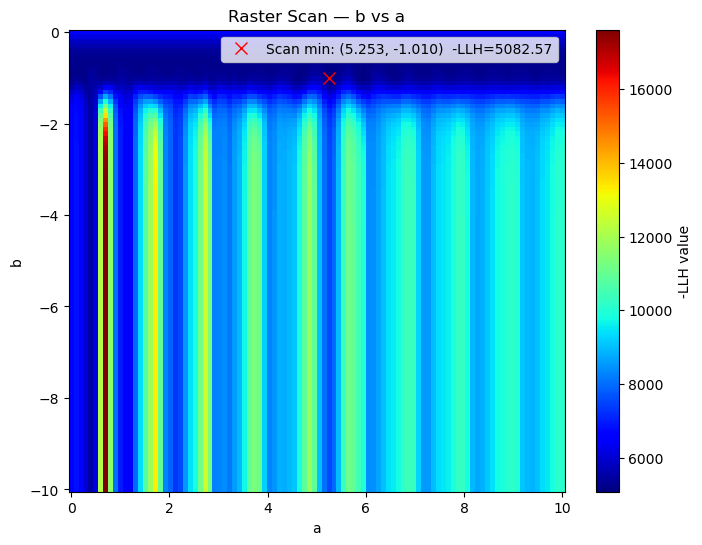

In [46]:
#Define and normalize the function: 
def f8(x, a, b, c, d):
    def sin_exp(x, a, b, c, d):
        return np.sin(a*x+d)+ c*np.exp(b*x)+1
    integral = quad(sin_exp, 6, 11, args=(a, b, c, d))[0]
    return sin_exp(x, a, b, c, d)/integral

def f8_cfixed(x, a, b):
    c = 5000
    d  = 0.1
    def sin_exp(x, a, b):
        return np.sin(a*x+d)+ c*np.exp(b*x)+1
    integral = quad(sin_exp, 6, 11, args=(a, b))[0]
    return sin_exp(x, a, b)/integral
raster_scan_llh(x1, f8_cfixed, {'a': (0, 10), 'b': (-10, 0)}, num_points=100)

((np.float64(5939.393939393939), np.float64(0.4257575757575757)),
 np.float64(5062.15109736229))

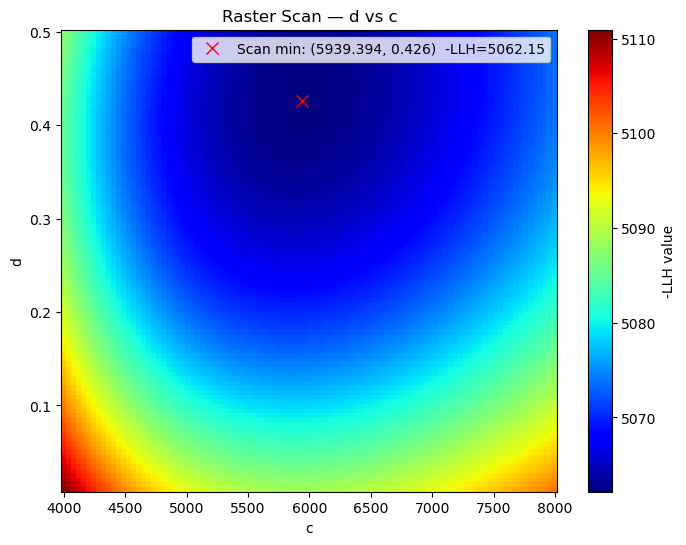

In [47]:
def f8_abfixed(x, c, d):
    a = 5.253
    b = -1.010
    def sin_exp(x, c, d):
        return np.sin(a*x+d)+ c*np.exp(b*x)+1
    integral = quad(sin_exp, 6, 11, args=(c, d))[0]
    return sin_exp(x, c, d)/integral

raster_scan_llh(x1, f8_abfixed, {'c': (4000, 8000), 'd': (0.01,0.5)}, num_points=100)

In [48]:
f8_params, f8_errors, f8_min_llh = minimizer(x1, f8, [5.253, -1.010, 5939.4,0.426 ], limits=[(5, 5.5), (-1.3,-0.8), (5800, 6000), (0.01,0.5)])

Estimated parameters: <ValueView x0=5.289994783852505 x1=-1.0033404187081478 x2=5800.006366309527 x3=0.08265998835239967>
Parameter errors: <ErrorView x0=0.14831675325678795 x1=0.014724122879774537 x2=101.54677861378923 x3=0.3225616624877601>
Minimum log-likelihood: 5061.78455165382


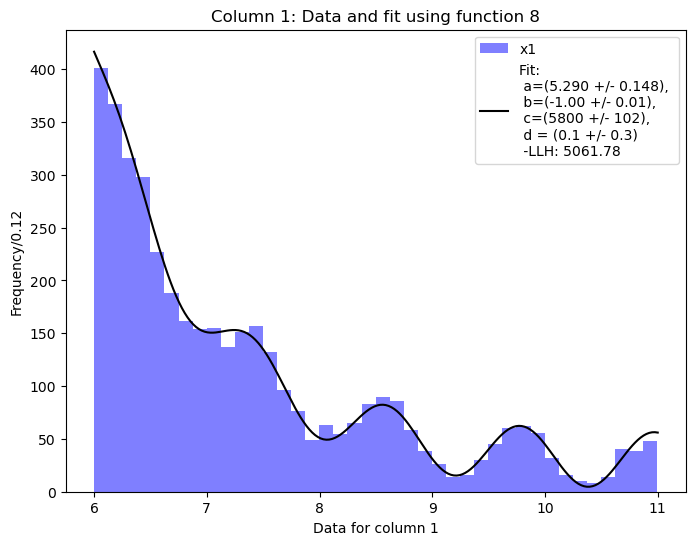

In [49]:
#plot the fit:

fig, ax = plt.subplots(figsize=(8, 6))
num_bins = 40
counts, bins, _ = ax.hist(x1, bins=num_bins, label='x1', alpha = 0.5, color = 'blue')
bin_width = (11-6)/num_bins
x1_fit = np.linspace(6, 11, 200)
y1_fit = f8(x1_fit, *f8_params)*bin_width*len(x1)
ax.plot(x1_fit, y1_fit, color='k', label=f'Fit: \n a=({f8_params[0]:.3f} +/- {f8_errors[0]:.3f}), \n b=({f8_params[1]:.2f} +/- {f8_errors[1]:.2f}), \n c=({f8_params[2]:.0f} +/- {f8_errors[2]:.0f}), \n d = ({f8_params[3]:.1f} +/- {f8_errors[3]:.1f}) \n -LLH: {f8_min_llh:.2f}')
ax.set_xlabel('Data for column 1')
ax.set_ylabel(f'Frequency/{bin_width:.2f}')
ax.set_title('Column 1: Data and fit using function 8')
ax.legend();


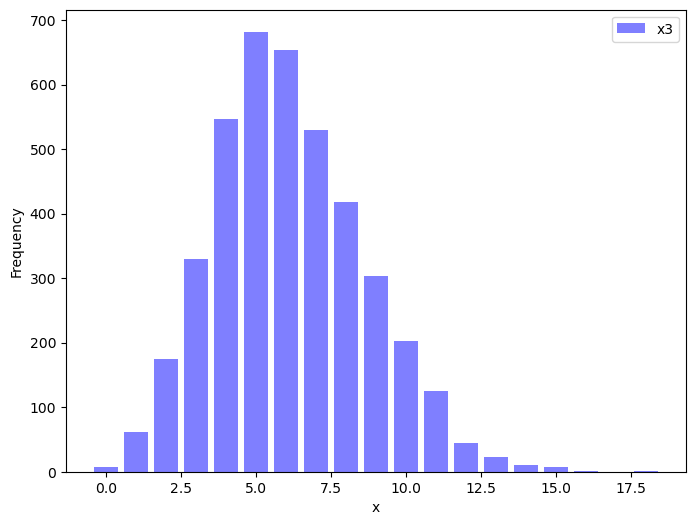

In [50]:
#Lets do third column. 
# First a bar-plot of x3: 
fig, ax = plt.subplots(figsize=(8, 6))
nvals, ncounts = np.unique(x3, return_counts=True)
ax.bar(nvals, ncounts, color='b', alpha=0.5, label = 'x3')
ax.set_xlabel('x')
ax.set_ylabel('Frequency')
ax.legend();


(np.float64(6.13030303030303), np.float64(9565.433803095433))

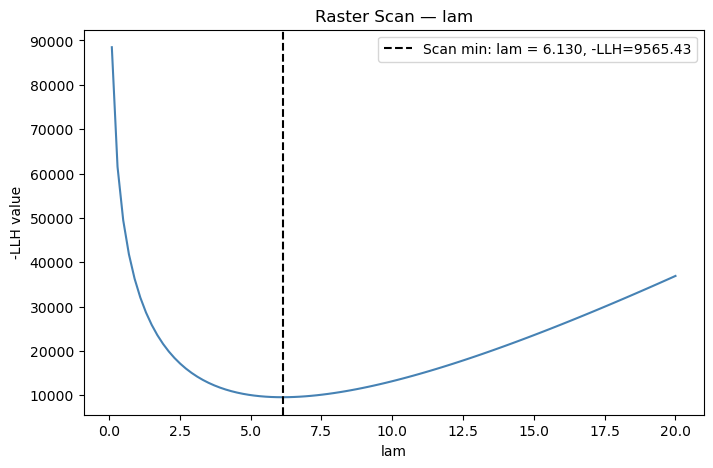

In [51]:
#looks a bit like a poisson distribution, so we can try to fit that:
def f11(x, lam):
    return stats.poisson.pmf(x, lam)

raster_scan_llh(x3, f11, {'lam': (0.1, 20)}, num_points=100)

In [52]:
print(np.mean(x3))

6.117689881096821


In [53]:
f11_params, f11_errors, f11_min_llh = minimizer(x3, f11, [np.mean(x3)], limits=[(0.1, 20)])

Estimated parameters: <ValueView x0=6.117689881096821>
Parameter errors: <ErrorView x0=0.054488498787360395>
Minimum log-likelihood: 9565.380292990612


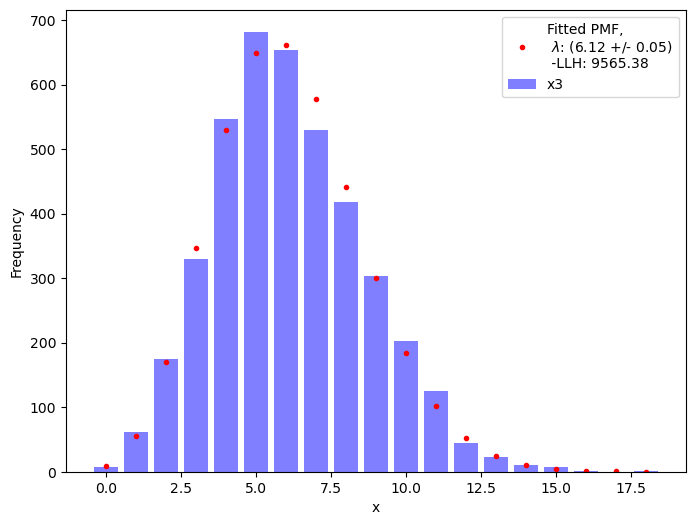

In [54]:
x3_vals = np.arange(0, max(x3)+1)
y3_vals = f11(x3_vals, *f11_params) * len(x3)


fig, ax = plt.subplots(figsize=(8, 6))
nvals, ncounts = np.unique(x3, return_counts=True)
ax.bar(nvals, ncounts, color='b', alpha=0.5, label = 'x3')
ax.plot(x3_vals, y3_vals, '.', label=f'Fitted PMF, \n $\\lambda$: ({f11_params[0]:.2f} +/- {f11_errors[0]:.2f}) \n -LLH: {f11_min_llh:.2f}', color='red')
ax.set_xlabel('x')
ax.set_ylabel('Frequency')
ax.legend();

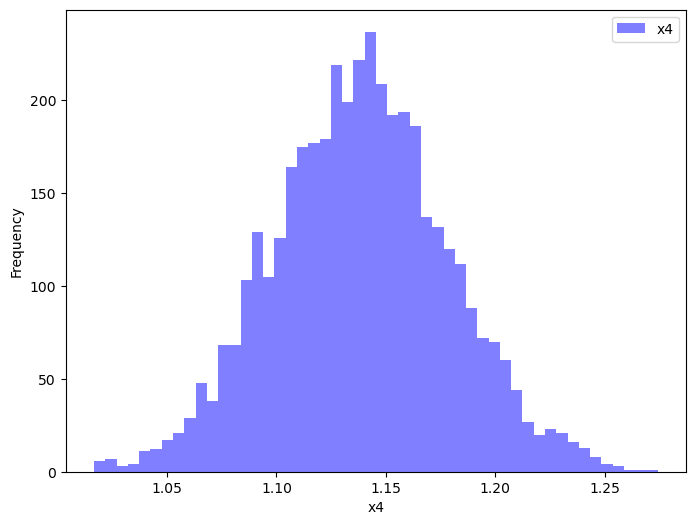

In [55]:
#Now fourth column: 
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(x4, bins=50, color='b', alpha=0.5, label = 'x4')
ax.set_xlabel('x4')
ax.set_ylabel('Frequency')
ax.legend();

In [56]:
def f9(x, a, b):
    def exp_gauss(x, a, b):
        return np.exp(-0.5*((x-a)/b)**2)
    integral = quad(exp_gauss, np.min(x4), np.max(x4), args=(a, b))[0]
    return exp_gauss(x, a, b)/integral

In [57]:
f9_params, f9_errors, f9_min_llh = minimizer(x4, f9, [np.mean(x4), np.std(x4)])

Estimated parameters: <ValueView x0=1.1384790362105615 x1=0.040195133161717765>
Parameter errors: <ErrorView x0=0.0008931483063185939 x1=0.0006566231304425775>
Minimum log-likelihood: -7438.4961244500855


In [58]:
print(np.mean(x4), np.std(x4))

1.1385878735743753 0.039857269691782195


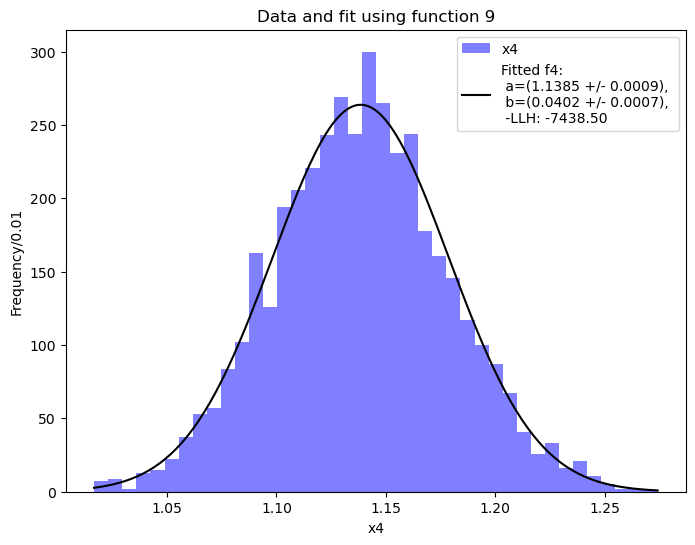

In [59]:
#plot the fit: 

fig, ax = plt.subplots(figsize=(8, 6))
num_bins = 40
counts, bins, _ = ax.hist(x4, bins=num_bins, label='x4', alpha = 0.5, color = 'blue')
bin_width = (np.max(x4)-np.min(x4))/num_bins
x4_fit = np.linspace(np.min(x4), np.max(x4), 200)
y4_fit = f9(x4_fit, *f9_params)*bin_width*len(x4)
ax.plot(x4_fit, y4_fit, color='k', label=f'Fitted f4: \n a=({f9_params[0]:.4f} +/- {f9_errors[0]:.4f}), \n b=({f9_params[1]:.4f} +/- {f9_errors[1]:.4f}), \n -LLH: {f9_min_llh:.2f}')
ax.set_xlabel('x4')
ax.set_ylabel(f'Frequency/{bin_width:.2f}')
ax.set_title('Data and fit using function 9')
ax.legend();

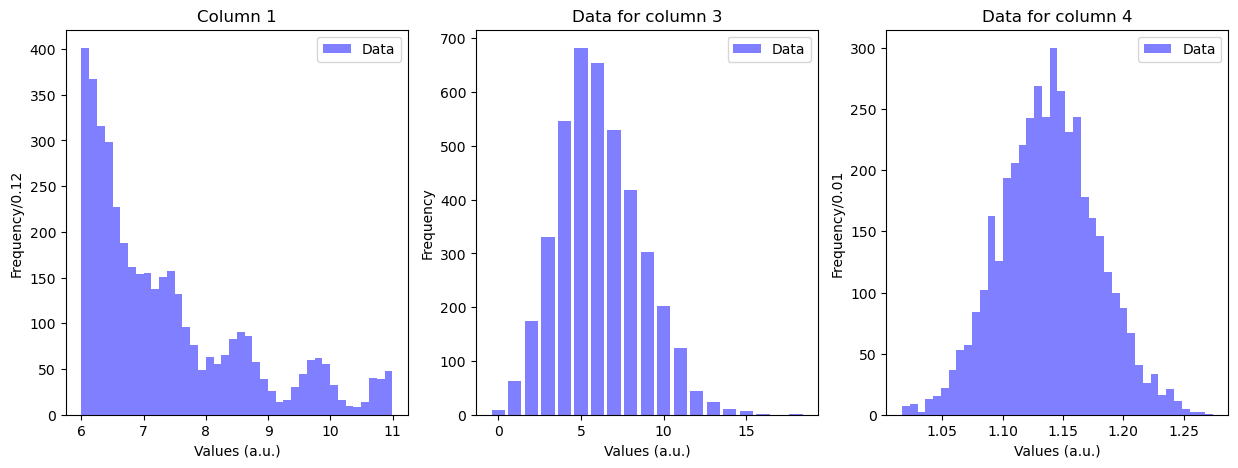

In [60]:
#At last plot all together without fit:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Column 1
num_bins = 40
counts, bins, _ = axes[0].hist(x1, bins=num_bins, label='Data', alpha = 0.5, color = 'b')
bin_width = (11-6)/num_bins
axes[0].set_xlabel('Values (a.u.)')
axes[0].set_ylabel(f'Frequency/{bin_width:.2f}')
axes[0].set_title('Column 1')
axes[0].legend();

#Column 3
nvals, ncounts = np.unique(x3, return_counts=True)
axes[1].bar(nvals, ncounts, color='b', label = 'Data', alpha = 0.5)
axes[1].set_xlabel('Values (a.u.)')
axes[1].set_title('Data for column 3')
axes[1].set_ylabel('Frequency')
axes[1].legend();

#Column 4
num_bins = 40
counts, bins, _ = axes[2].hist(x4, bins=num_bins, label='Data', alpha =0.5, color = 'b')
bin_width = (np.max(x4)-np.min(x4))/num_bins    
axes[2].set_xlabel('Values (a.u.)')
axes[2].set_title('Data for column 4')
axes[2].set_ylabel(f'Frequency/{bin_width:.2f}')
axes[2].legend();


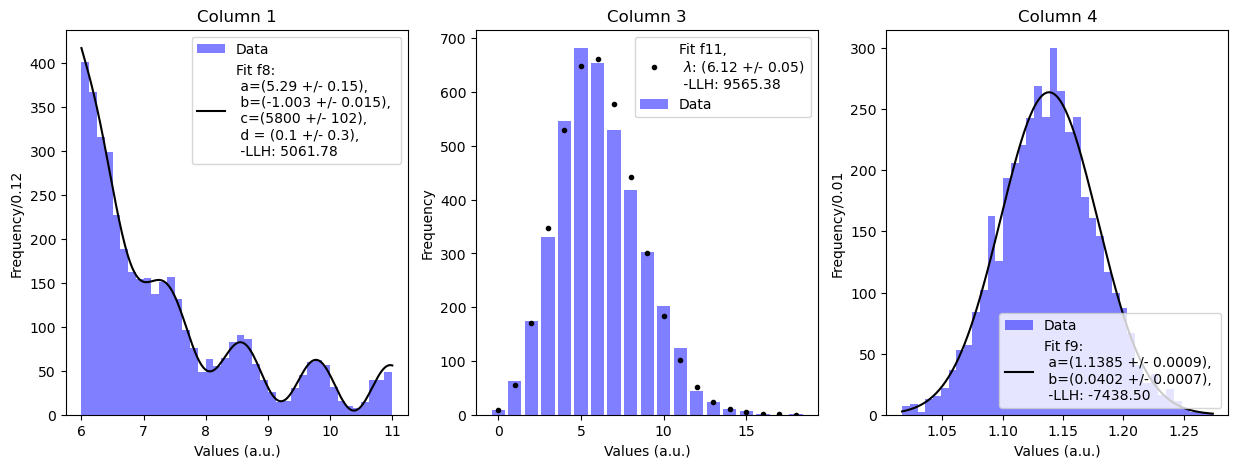

In [61]:
#At last plot all together:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Column 1
num_bins = 40
counts, bins, _ = axes[0].hist(x1, bins=num_bins, label='Data', alpha = 0.5, color = 'blue')
bin_width = (11-6)/num_bins
x1_fit = np.linspace(6, 11, 200)
y1_fit = f8(x1_fit, *f8_params)*bin_width*len(x1)
axes[0].plot(x1_fit, y1_fit, color='k', label=f'Fit f8: \n a=({f8_params[0]:.2f} +/- {f8_errors[0]:.2f}), \n b=({f8_params[1]:.3f} +/- {f8_errors[1]:.3f}), \n c=({f8_params[2]:.0f} +/- {f8_errors[2]:.0f}), \n d = ({f8_params[3]:.1f} +/- {f8_errors[3]:.1f}), \n -LLH: {f8_min_llh:.2f}')
axes[0].set_xlabel('Values (a.u.)')
axes[0].set_ylabel(f'Frequency/{bin_width:.2f}')
axes[0].set_title('Column 1')
axes[0].legend();

#Column 3
nvals, ncounts = np.unique(x3, return_counts=True)
axes[1].bar(nvals, ncounts, color='b', alpha=0.5, label = 'Data')
axes[1].plot(x3_vals, y3_vals, '.', label=f'Fit f11, \n $\\lambda$: ({f11_params[0]:.2f} +/- {f11_errors[0]:.2f}) \n -LLH: {f11_min_llh:.2f}', color='k')
axes[1].set_xlabel('Values (a.u.)') 
axes[1].set_title('Column 3')
axes[1].set_ylabel('Frequency')
axes[1].legend();

#Column 4
num_bins = 40
counts, bins, _ = axes[2].hist(x4, bins=num_bins, label='Data', alpha = 0.5, color = 'blue')
bin_width = (np.max(x4)-np.min(x4))/num_bins    
x4_fit = np.linspace(np.min(x4), np.max(x4), 200)
y4_fit = f9(x4_fit, *f9_params)*bin_width*len(x4)
axes[2].plot(x4_fit, y4_fit, color='k', label=f'Fit f9: \n a=({f9_params[0]:.4f} +/- {f9_errors[0]:.4f}), \n b=({f9_params[1]:.4f} +/- {f9_errors[1]:.4f}), \n -LLH: {f9_min_llh:.2f}')
axes[2].set_xlabel('Values (a.u.)')
axes[2].set_title('Column 4')
axes[2].set_ylabel(f'Frequency/{bin_width:.2f}')
axes[2].legend(loc ='lower right');


## Sample MC and do KS test to get p-values.

In [62]:
#Lets now sample from the fitted distributions and compare to data:
#Column 1
def sample_f8(x):
    func = f8(x, *f8_params)
    return func

def sample_f11(x):
    func = f11(x, *f11_params)
    return func

def sample_f9(x):
    func = f9(x, *f9_params)
    return func

In [63]:
def mc_modelsampls(func, xmin, xmax, n_samples):
    n_accepted = 0
    x_accepted = []
    hit_goal = False

    func_min, func_max = func(np.linspace(xmin, xmax, 1000)).min(), func(np.linspace(xmin, xmax, 1000)).max()

    while not hit_goal:
        x_val = r.uniform(xmin, xmax)
        y_val = r.uniform(func_min, func_max)

        if y_val < func(x_val):
            x_accepted.append(x_val)
            n_accepted += 1
        
        if n_accepted >= n_samples:
            hit_goal = True

    return np.array(x_accepted)


In [64]:
x1_sampled = mc_modelsampls(sample_f8, 6, 11, len(x1))
x3_sampled = np.random.poisson(*f11_params, size=len(x3))
x4_sampled = mc_modelsampls(sample_f9, np.min(x4), np.max(x4), len(x4))

In [65]:
from scipy import stats
ks_statistic_x1, p_value_x1 = stats.kstest(x1, x1_sampled)
ks_statistic_x3, p_value_x3 = stats.kstest(x3, x3_sampled)
ks_statistic_x4, p_value_x4 = stats.kstest(x4, x4_sampled)

print(f"KS test for x1: statistic={ks_statistic_x1:.4f}, p-value={p_value_x1:.4f}")
print(f"KS test for x3: statistic={ks_statistic_x3:.4f}, p-value={p_value_x3:.4f}")
print(f"KS test for x4: statistic={ks_statistic_x4:.4f}, p-value={p_value_x4:.4f}")

#Make a DF and print a latex table:
results_df = pd.DataFrame({
    'Column': ['Col. 1', 'Col. 3', 'Col. 4'],
    'KS Statistic': [ks_statistic_x1, ks_statistic_x3, ks_statistic_x4],
    'p-value': [p_value_x1, p_value_x3, p_value_x4]
})
print(results_df.to_latex(index=False, float_format="%.4f"))

KS test for x1: statistic=0.0233, p-value=0.2135
KS test for x3: statistic=0.0143, p-value=0.7923
KS test for x4: statistic=0.0158, p-value=0.6846
\begin{tabular}{lrr}
\toprule
Column & KS Statistic & p-value \\
\midrule
Col. 1 & 0.0233 & 0.2135 \\
Col. 3 & 0.0143 & 0.7923 \\
Col. 4 & 0.0158 & 0.6846 \\
\bottomrule
\end{tabular}



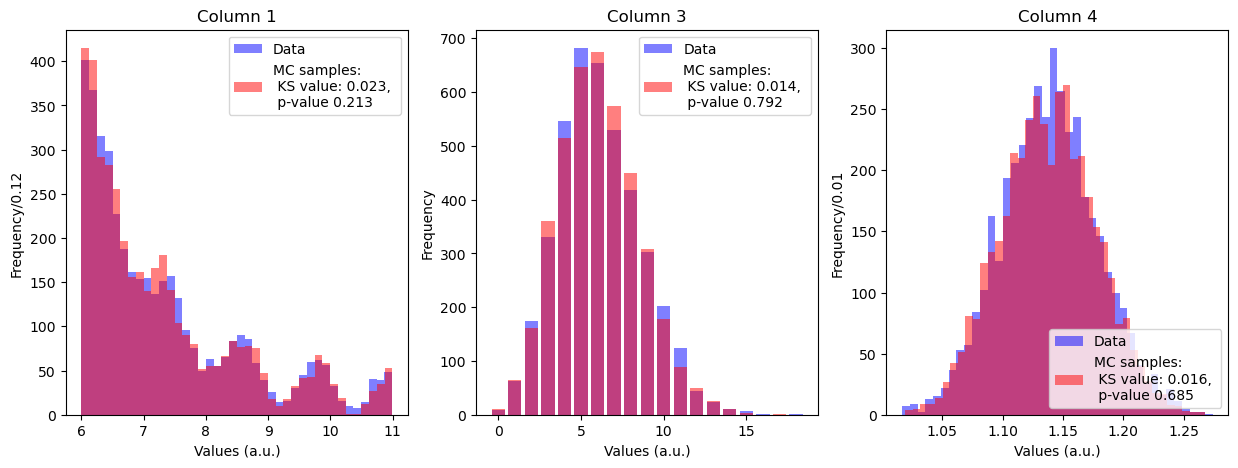

In [66]:
#Plot the sampled data against the original data:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Column 1
num_bins = 40
counts, bins, _ = axes[0].hist(x1, bins=num_bins, label='Data', alpha = 0.5, color = 'blue')
bin_width = (11-6)/num_bins
axes[0].hist(x1_sampled, bins=num_bins, label=f'MC samples: \n KS value: {ks_statistic_x1:.3f}, \n p-value {p_value_x1:.3f}', alpha = 0.5, color = 'red')
axes[0].set_xlabel('Values (a.u.)')    
axes[0].set_ylabel(f'Frequency/{bin_width:.2f}')
axes[0].set_title('Column 1')
axes[0].legend();

#Column 3
nvals, ncounts = np.unique(x3, return_counts=True)
nvals_sampled, ncounts_sampled = np.unique(x3_sampled, return_counts=True)
axes[1].bar(nvals, ncounts, color='b', alpha =0.5, label = 'Data')
axes[1].bar(nvals_sampled, ncounts_sampled, label=f'MC samples: \n KS value: {ks_statistic_x3:.3f}, \n p-value {p_value_x3:.3f}', alpha = 0.5, color = 'red')
axes[1].set_title('Column 3')
axes[1].set_xlabel('Values (a.u.)')
axes[1].set_ylabel('Frequency')
axes[1].legend();

#Column 4
num_bins = 40
counts, bins, _ = axes[2].hist(x4, bins=num_bins, label='Data', alpha =0.5, color = 'b')
bin_width = (np.max(x4)-np.min(x4))/num_bins 
axes[2].hist(x4_sampled, bins=num_bins, label=f'MC samples: \n KS value: {ks_statistic_x4:.3f}, \n p-value {p_value_x4:.3f}', alpha = 0.5, color = 'red')  
axes[2].set_title('Column 4')
axes[2].set_xlabel('Values (a.u.)')
axes[2].set_ylabel(f'Frequency/{bin_width:.2f}')
axes[2].legend(loc = 'lower right');

In [74]:
# Summarize best fit parameters and their errors in a LaTeX table, alongside the KS test results, with max 3 decimal points for the parameters, using the requested template style with three columns.

# Extract values for the table
a_val, a_err = f8_params[0], f8_errors[0]
b_val, b_err = f8_params[1], f8_errors[1]
c_val, c_err = f8_params[2], f8_errors[2]
d_val, d_err = f8_params[3], f8_errors[3]
lambda_val, lambda_err = f11_params[0], f11_errors[0]
f9_a_val, f9_a_err = f9_params[0], f9_errors[0]
f9_b_val, f9_b_err = f9_params[1], f9_errors[1]

# KS and p-values
ks1, ks3, ks4 = ks_statistic_x1, ks_statistic_x3, ks_statistic_x4
pval1, pval3, pval4 = p_value_x1, p_value_x3, p_value_x4

latex_table = r'''
\begin{{table}}[h!]
\centering
\begin{{tabular}}{{l|c|c|c}}
\hline
 & \textbf{{Column 1}} & \textbf{{Column 3}} & \textbf{{Column 4}} \\
 & Fit f8 & Fit f11 & Fit f9 \\
\hline
$a$ & ${:.3f} \pm {:.3f}$ & - & ${:.4f} \pm {:.4f}$ \\
$b$ & ${:.3f} \pm {:.3f}$ & - & ${:.4f} \pm {:.4f}$ \\
$c$ & ${:.0f} \pm {:.0f}$ & - & - \\
$d$ & ${:.2f} \pm {:.2f}$ & - & - \\
$\lambda$ & - & ${:.2f} \pm {:.2f}$ & - \\
\hline
KS statistic & {:.3f} & {:.3f} & {:.3f} \\
p-value & {:.3f} & {:.3f} & {:.3f} \\
\hline
\end{{tabular}}
\caption{{}}
\end{{table}}
'''.format(
    a_val, a_err, f9_a_val, f9_a_err,
    b_val, b_err, f9_b_val, f9_b_err,
    c_val, c_err,
    d_val, d_err,
    lambda_val, lambda_err,
    ks1, ks3, ks4,
    pval1, pval3, pval4
)

print(latex_table)


\begin{table}[h!]
\centering
\begin{tabular}{l|c|c|c}
\hline
 & \textbf{Column 1} & \textbf{Column 3} & \textbf{Column 4} \\
 & Fit f8 & Fit f11 & Fit f9 \\
\hline
$a$ & $5.290 \pm 0.148$ & - & $1.1385 \pm 0.0009$ \\
$b$ & $-1.003 \pm 0.015$ & - & $0.0402 \pm 0.0007$ \\
$c$ & $5800 \pm 102$ & - & - \\
$d$ & $0.08 \pm 0.32$ & - & - \\
$\lambda$ & - & $6.12 \pm 0.05$ & - \\
\hline
KS statistic & 0.023 & 0.014 & 0.016 \\
p-value & 0.213 & 0.792 & 0.685 \\
\hline
\end{tabular}
\caption{}
\end{table}

